In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np


Kích thước ảnh: (400, 267)
Chế độ màu gốc: RGBA
Chế độ màu xám: L
Số lượng giá trị trong histogram: 256
Tổng số pixel: 106800
Pixel có giá trị 0: 0
Pixel có giá trị 255: 0


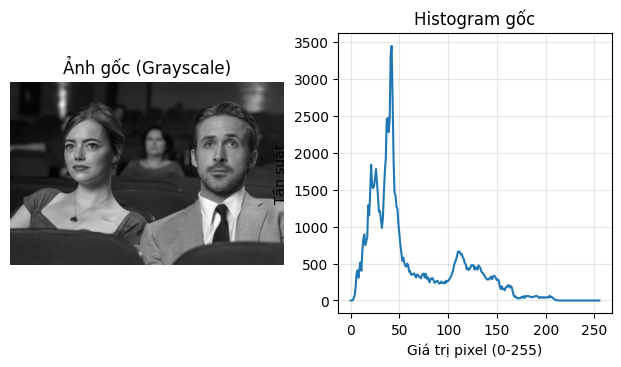

In [4]:
img = Image.open("/content/drive/MyDrive/Lab_Images/bai3_flip_horizontal.png")

# Chuyển sang ảnh xám để dễ phân tích histogram
gray_img = img.convert('L')

print(f"Kích thước ảnh: {img.size}")
print(f"Chế độ màu gốc: {img.mode}")
print(f"Chế độ màu xám: {gray_img.mode}")
# Tính histogram - trả về list 256 phần tử (0-255)
histogram = gray_img.histogram()

print(f"Số lượng giá trị trong histogram: {len(histogram)}")
print(f"Tổng số pixel: {sum(histogram)}")
print(f"Pixel có giá trị 0: {histogram[0]}")
print(f"Pixel có giá trị 255: {histogram[255]}")
plt.figure(figsize=(12, 8))

# Subplot 1: Ảnh xám gốc
plt.subplot(2, 3, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('Ảnh gốc (Grayscale)')
plt.axis('off')

# Subplot 2: Histogram gốc
plt.subplot(2, 3, 2)
plt.plot(histogram)
plt.title('Histogram gốc')
plt.xlabel('Giá trị pixel (0-255)')
plt.ylabel('Tần suất')
plt.grid(True, alpha=0.3)

plt.show()

✓ Đã cân bằng histogram và lưu file


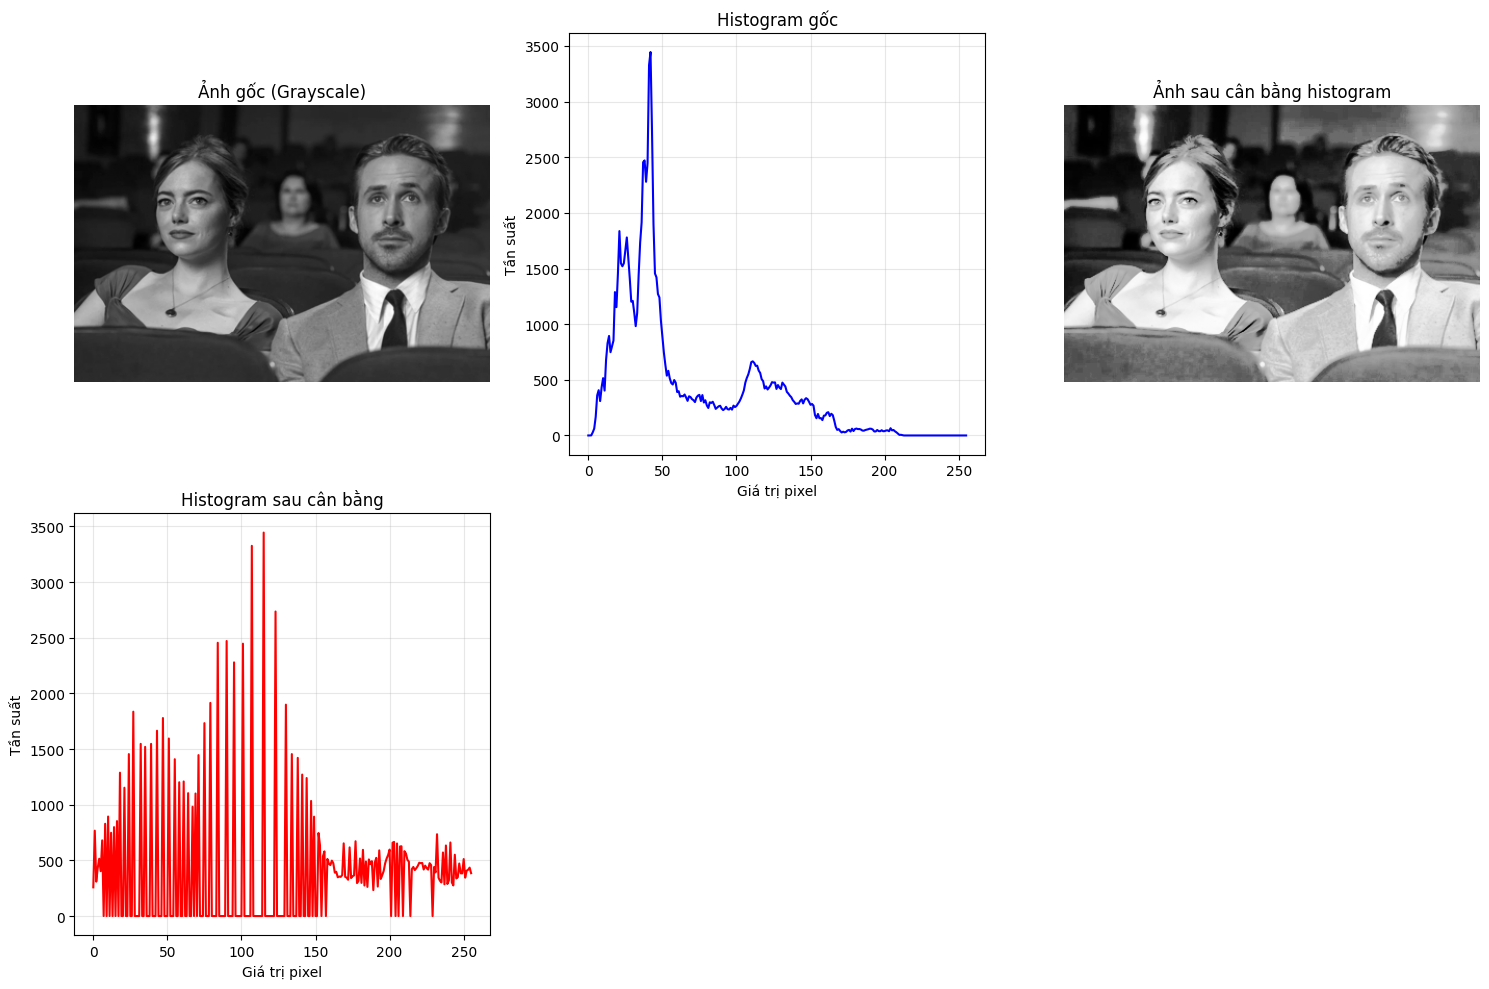

In [5]:
# Cân bằng histogram để cải thiện độ tương phản
equalized_img = ImageOps.equalize(gray_img)
equalized_histogram = equalized_img.histogram()

# Lưu ảnh đã cân bằng
equalized_img.save("/content/bai9_equalized.jpg")
print("✓ Đã cân bằng histogram và lưu file")
plt.figure(figsize=(15, 10))

# Ảnh gốc
plt.subplot(2, 3, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('Ảnh gốc (Grayscale)')
plt.axis('off')
plt.subplot(2, 3, 2)
plt.plot(histogram, color='blue')
plt.title('Histogram gốc')
plt.xlabel('Giá trị pixel')
plt.ylabel('Tần suất')
plt.grid(True, alpha=0.3)

# Ảnh sau cân bằng
plt.subplot(2, 3, 3)
plt.imshow(equalized_img, cmap='gray')
plt.title('Ảnh sau cân bằng histogram')
plt.axis('off')

# Histogram sau cân bằng
plt.subplot(2, 3, 4)
plt.plot(equalized_histogram, color='red')
plt.title('Histogram sau cân bằng')
plt.xlabel('Giá trị pixel')
plt.ylabel('Tần suất')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



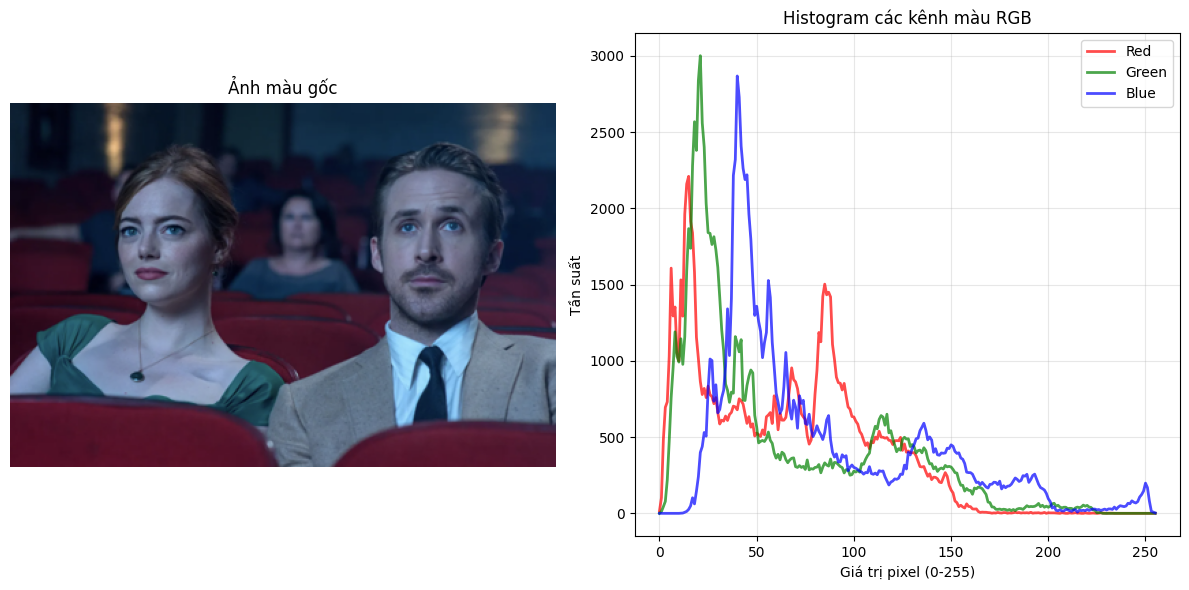

In [7]:
img=img.convert('RGB')

# Phân tích histogram cho ảnh màu
if img.mode == 'RGB':
    # Tách các kênh màu Red, Green, Blue
    r, g, b = img.split()

    # Tính histogram cho từng kênh
    hist_r = r.histogram()
    hist_g = g.histogram()
    hist_b = b.histogram()

    plt.figure(figsize=(12, 6))

    # Hiển thị ảnh màu gốc
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title('Ảnh màu gốc')
    plt.axis('off')

    # Vẽ histogram 3 kênh màu
    plt.subplot(1, 2, 2)
    plt.plot(hist_r, color='red', alpha=0.7, label='Red', linewidth=2)
    plt.plot(hist_g, color='green', alpha=0.7, label='Green', linewidth=2)
    plt.plot(hist_b, color='blue', alpha=0.7, label='Blue', linewidth=2)
    plt.title('Histogram các kênh màu RGB')
    plt.xlabel('Giá trị pixel (0-255)')
    plt.ylabel('Tần suất')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Ảnh không ở chế độ RGB")


In [8]:
gray_array = np.array(gray_img)
equalized_array = np.array(equalized_img)

# Tính các thông số thống kê
print("=== THỐNG KÊ HISTOGRAM ===")
print(f"\nẢnh gốc:")
print(f"  Mean (trung bình): {np.mean(gray_array):.2f}")
print(f"  Std (độ lệch chuẩn): {np.std(gray_array):.2f}")
print(f"  Min (giá trị nhỏ nhất): {np.min(gray_array)}")
print(f"  Max (giá trị lớn nhất): {np.max(gray_array)}")

print(f"\nẢnh sau cân bằng:")
print(f"  Mean: {np.mean(equalized_array):.2f}")
print(f"  Std: {np.std(equalized_array):.2f}")
print(f"  Min: {np.min(equalized_array)}")
print(f"  Max: {np.max(equalized_array)}")


=== THỐNG KÊ HISTOGRAM ===

Ảnh gốc:
  Mean (trung bình): 63.03
  Std (độ lệch chuẩn): 44.64
  Min (giá trị nhỏ nhất): 2
  Max (giá trị lớn nhất): 212

Ảnh sau cân bằng:
  Mean: 126.36
  Std: 74.27
  Min: 0
  Max: 255


In [9]:
def calculate_entropy(histogram):
    """Tính entropy của histogram - đo lường độ phức tạp thông tin"""
    total_pixels = sum(histogram)
    entropy = 0

    for count in histogram:
        if count > 0:  # Tránh log(0)
            p = count / total_pixels  # Xác suất
            entropy -= p * np.log2(p)  # Công thức entropy

    return entropy

# Tính entropy cho cả 2 ảnh
entropy_original = calculate_entropy(histogram)
entropy_equalized = calculate_entropy(equalized_histogram)

print(f"\n=== ENTROPY (ĐỘ ĐO THÔNG TIN) ===")
print(f"Entropy ảnh gốc: {entropy_original:.2f} bits")
print(f"Entropy sau cân bằng: {entropy_equalized:.2f} bits")

if entropy_equalized > entropy_original:
    print("✓ Cân bằng histogram đã tăng thông tin trong ảnh")
else:
    print(" Cân bằng histogram có thể đã làm giảm thông tin")



=== ENTROPY (ĐỘ ĐO THÔNG TIN) ===
Entropy ảnh gốc: 6.97 bits
Entropy sau cân bằng: 6.78 bits
 Cân bằng histogram có thể đã làm giảm thông tin


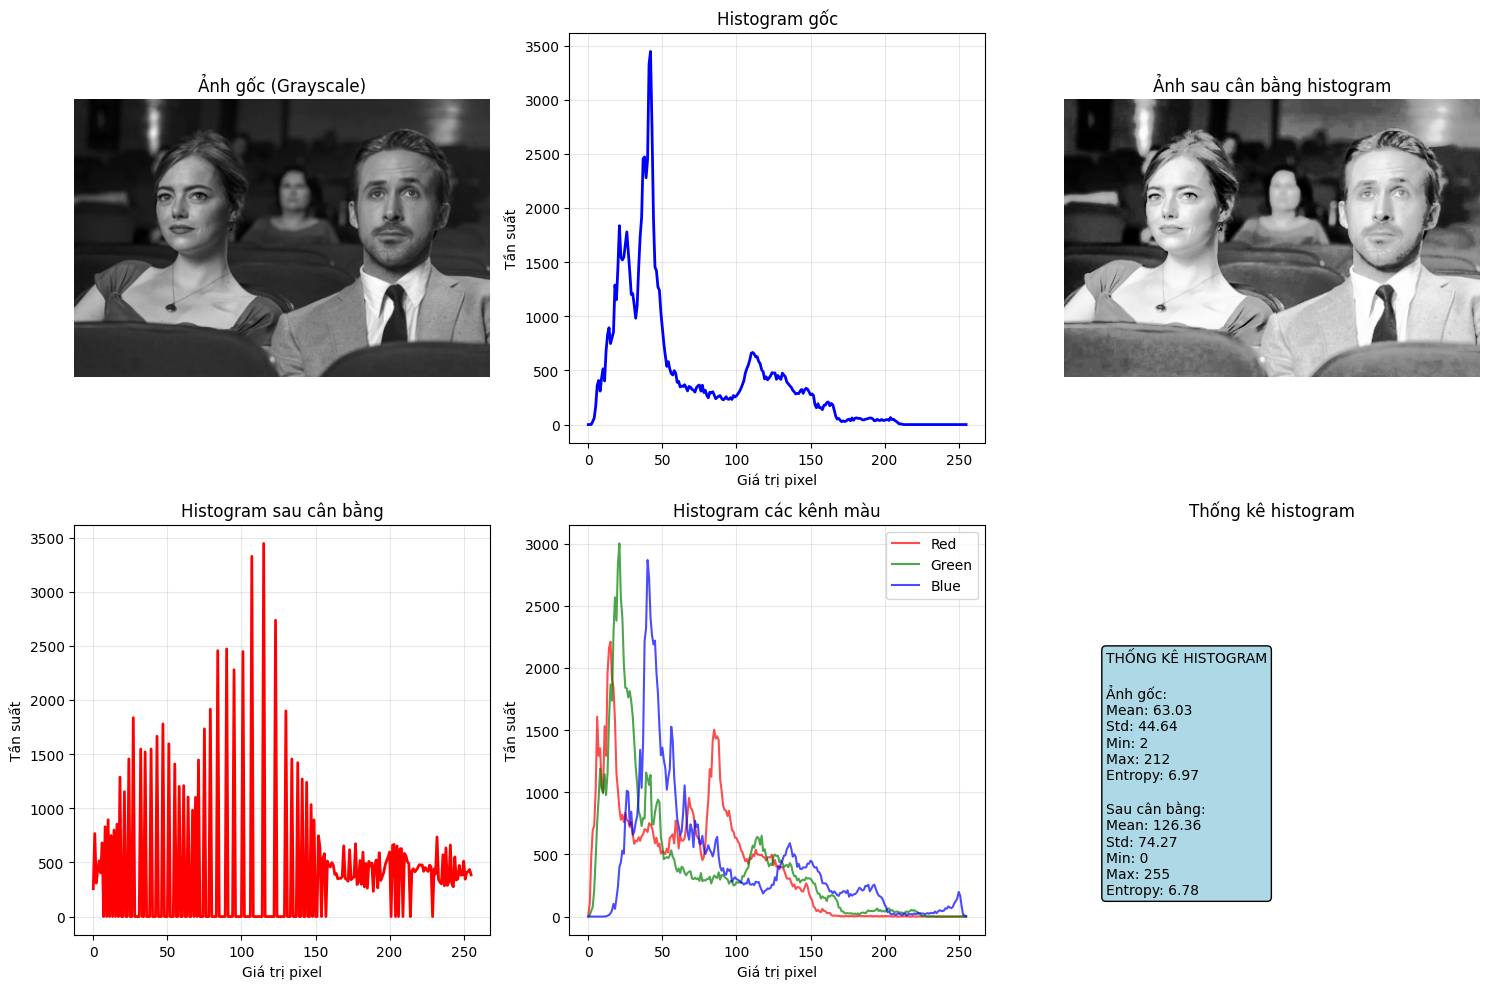

Bài 9 hoàn thành!
Đã lưu:
  - bai9_equalized.jpg (ảnh sau cân bằng)
  - bai9_histogram_analysis.png (biểu đồ phân tích)


In [10]:
plt.figure(figsize=(15, 10))

# Ảnh gốc
plt.subplot(2, 3, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('Ảnh gốc (Grayscale)')
plt.axis('off')

# Histogram gốc
plt.subplot(2, 3, 2)
plt.plot(histogram, color='blue', linewidth=2)
plt.title('Histogram gốc')
plt.xlabel('Giá trị pixel')
plt.ylabel('Tần suất')
plt.grid(True, alpha=0.3)

# Ảnh sau cân bằng
plt.subplot(2, 3, 3)
plt.imshow(equalized_img, cmap='gray')
plt.title('Ảnh sau cân bằng histogram')
plt.axis('off')

# Histogram sau cân bằng
plt.subplot(2, 3, 4)
plt.plot(equalized_histogram, color='red', linewidth=2)
plt.title('Histogram sau cân bằng')
plt.xlabel('Giá trị pixel')
plt.ylabel('Tần suất')
plt.grid(True, alpha=0.3)

# Histogram màu (nếu có)
plt.subplot(2, 3, 5)
if img.mode == 'RGB':
    plt.plot(hist_r, color='red', alpha=0.7, label='Red')
    plt.plot(hist_g, color='green', alpha=0.7, label='Green')
    plt.plot(hist_b, color='blue', alpha=0.7, label='Blue')
    plt.title('Histogram các kênh màu')
    plt.xlabel('Giá trị pixel')
    plt.ylabel('Tần suất')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Bảng thống kê
plt.subplot(2, 3, 6)
stats_text = f"""THỐNG KÊ HISTOGRAM

Ảnh gốc:
Mean: {np.mean(gray_array):.2f}
Std: {np.std(gray_array):.2f}
Min: {np.min(gray_array)}
Max: {np.max(gray_array)}
Entropy: {entropy_original:.2f}

Sau cân bằng:
Mean: {np.mean(equalized_array):.2f}
Std: {np.std(equalized_array):.2f}
Min: {np.min(equalized_array)}
Max: {np.max(equalized_array)}
Entropy: {entropy_equalized:.2f}"""

plt.text(0.1, 0.1, stats_text, fontsize=10,
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
plt.title('Thống kê histogram')
plt.axis('off')

plt.tight_layout()
plt.savefig("/content/bai9_histogram_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print("Bài 9 hoàn thành!")
print("Đã lưu:")
print("  - bai9_equalized.jpg (ảnh sau cân bằng)")
print("  - bai9_histogram_analysis.png (biểu đồ phân tích)")
